SETUP

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
import re, html
import itertools
import time
DATA_DIR = "winter_project_2026"
DEV_PATH = f"{DATA_DIR}/development.csv"
EVAL_PATH = f"{DATA_DIR}/evaluation.csv"
SAMPLE_SUB_PATH = f"{DATA_DIR}/sample_submission.csv"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


LOADING DATA

In [3]:
df = pd.read_csv(DEV_PATH)
df.head(3)
df_eval = pd.read_csv(EVAL_PATH)
df_eval.head()

,Id,source,title,article,page_rank,timestamp
0,0,Guardian,Radio appeal unearths missing pickle recipe,A plea by Chris Evans on Radio 2 for the retur...,5,2008-01-27 04:37:04
1,1,CNET,Vonage loses appeal in Verizon patent case,The Internet phone provider now faces paying o...,3,2007-09-27 04:00:25
2,2,Xinhua,Italy launches major offensive against organiz...,Italian Police launched a major offensive agai...,5,2004-12-08 02:21:45
3,3,BBC,BAE 'to appoint ethics committee',BAE Systems is reported to be planning to set ...,5,2007-06-10 15:35:07
4,4,Ha'aretz,US envoy Bolton to stop here on way to nuclear...,A senior US official will visit Israel for con...,5,0000-00-00 00:00:00


In [4]:
df.shape, df.columns.tolist()

((79997, 7),
 ['Id', 'source', 'title', 'article', 'page_rank', 'timestamp', 'label'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79997 entries, 0 to 79996
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         79997 non-null  int64 
 1   source     79997 non-null  object
 2   title      79996 non-null  object
 3   article    79996 non-null  object
 4   page_rank  79997 non-null  int64 
 5   timestamp  79997 non-null  object
 6   label      79997 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 4.3+ MB


In [6]:
df["title"] = df["title"].fillna("")
df["article"] = df["article"].fillna("")
df_eval["title"] = df_eval["title"].fillna("")
df_eval["article"] = df_eval["article"].fillna("")
label_counts = df["label"].value_counts().sort_index()
label_counts

label
0    23542
1    10588
2    11161
3     9977
4     8574
5    13053
6     3102
Name: count, dtype: int64

In [7]:
(label_counts / len(df)).round(4)

label
0    0.2943
1    0.1324
2    0.1395
3    0.1247
4    0.1072
5    0.1632
6    0.0388
Name: count, dtype: float64

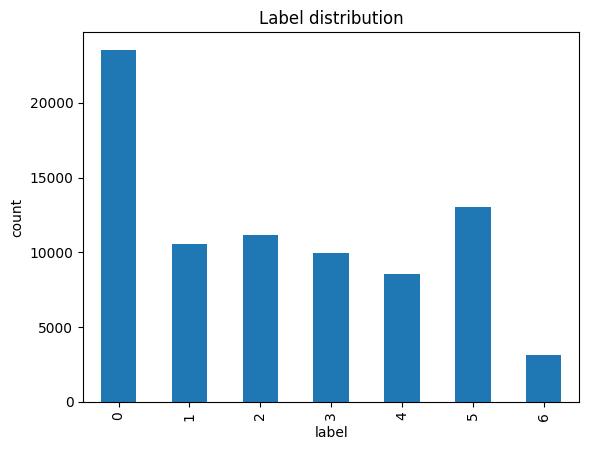

In [8]:
plt.figure()
label_counts.plot(kind="bar")
plt.title("Label distribution")
plt.xlabel("label")
plt.ylabel("count")
plt.show()

The dataset presents a moderate class imbalance, with label 6 representing only ~4% of the samples.
Since the evaluation metric is Macro F1, special care must be taken to avoid bias towards majority classes.

In [333]:
df["Id"].nunique(), len(df)

(79997, 79997)

In [334]:
(df["title"].str.len() == 0).mean(), (df["article"].str.len() == 0).mean()

(np.float64(1.2500468767578784e-05), np.float64(1.2500468767578784e-05))

In [335]:
df[df["article"].str.split().str.len() < 5].shape[0]

2389

In [336]:
df["title"].str.contains("&#").mean()

np.float64(0.04520169506356488)

In [337]:
df["source"].nunique()

1359

In [338]:
(df["source"].value_counts() == 1).mean()

np.float64(0.3524650478292862)

In [339]:
df["page_rank"].min(), df["page_rank"].max()

(np.int64(2), np.int64(5))

In [340]:
df["page_rank"].describe(percentiles=[.95, .99])

count    79997.000000
mean         4.892958
std          0.397603
min          2.000000
50%          5.000000
95%          5.000000
99%          5.000000
max          5.000000
Name: page_rank, dtype: float64

In [341]:
ts = pd.to_datetime(df["timestamp"], errors="coerce")
ts.isna().mean()

np.float64(0.34688800830031125)

Timestamp not reliable

In [342]:
df["article"].str.contains("label", case=False).mean()

np.float64(0.0020000750028126056)

In [343]:
df.groupby("source")["label"].nunique().max()

np.int64(7)

In [13]:
df["text"] = (df["title"] + " " + df["article"]).str.strip()
df = df.drop(columns=["title", "article"])
df_eval["text"] = (df_eval["title"] + " " + df_eval["article"]).str.strip()
df_eval = df_eval.drop(columns=["title", "article"])
df["text"].str.len().describe()

count    79997.000000
mean       317.809555
std        355.505320
min          2.000000
25%        182.000000
50%        237.000000
75%        287.000000
max      15822.000000
Name: text, dtype: float64

In [14]:
df["text_len"] = df["text"].str.split().str.len()
df_eval["text_len"] = df_eval["text"].str.split().str.len()
df["text_len"].describe(percentiles=[.5, .75, .9, .95, .99]).round(2)

count    79997.00
mean        42.76
std         39.82
min          1.00
50%         37.00
75%         45.00
90%         66.00
95%         95.00
99%        136.00
max       1893.00
Name: text_len, dtype: float64

In [346]:
df.groupby("label")["text_len"].mean().round(1)

label
0    46.1
1    35.4
2    54.9
3    43.1
4    43.4
5    32.2
6    40.2
Name: text_len, dtype: float64

In [347]:
cv = CountVectorizer(min_df=5,stop_words="english")

X_counts = cv.fit_transform(df["text"])
len(cv.vocabulary_)

24297

In [348]:
word_freq = np.asarray(X_counts.sum(axis=0)).ravel()
words = np.array(cv.get_feature_names_out())

top_idx = word_freq.argsort()[::-1][:30]
list(zip(words[top_idx], word_freq[top_idx]))

[('com', np.int64(54557)),
 ('http', np.int64(47318)),
 ('img', np.int64(30565)),
 ('ap', np.int64(27317)),
 ('reuters', np.int64(23170)),
 ('src', np.int64(20842)),
 ('rss', np.int64(19718)),
 ('href', np.int64(19235)),
 ('border', np.int64(18351)),
 ('feeds', np.int64(18033)),
 ('39', np.int64(15827)),
 ('said', np.int64(15788)),
 ('new', np.int64(15361)),
 ('news', np.int64(14332)),
 ('yahoo', np.int64(14114)),
 ('130', np.int64(13436)),
 ('yimg', np.int64(13394)),
 ('afp', np.int64(11707)),
 ('height', np.int64(10063)),
 ('width', np.int64(10049)),
 ('left', np.int64(8435)),
 ('computerworld', np.int64(8358)),
 ('world', np.int64(8030)),
 ('alt', np.int64(7743)),
 ('clear', np.int64(7590)),
 ('br', np.int64(7488)),
 ('align', np.int64(7328)),
 ('pcworld', np.int64(7025)),
 ('rd', np.int64(6702)),
 ('dailynews', np.int64(6701))]

most articles have HTML in it, not normal language!

In [410]:

CUSTOM_STOP_WORDS = set(ENGLISH_STOP_WORDS).union({
    "com", "http", "img", "src", "href",
    "rss", "feeds", "yimg",
    "height", "width", "border",
    "align", "br", "alt", "clear", "left", "39", "130", "jpg", "photo", "sig",
    "quot", "div", "rd", "capt"
})

cv = CountVectorizer(min_df=5, stop_words=sorted(CUSTOM_STOP_WORDS))

X_counts = cv.fit_transform(df["text"])
word_freq = np.asarray(X_counts.sum(axis=0)).ravel()
words = np.array(cv.get_feature_names_out())

top_idx = word_freq.argsort()[::-1][:30]
list(zip(words[top_idx], word_freq[top_idx]))

[('ap', np.int64(27317)),
 ('reuters', np.int64(23170)),
 ('said', np.int64(15788)),
 ('new', np.int64(15361)),
 ('news', np.int64(14332)),
 ('yahoo', np.int64(14114)),
 ('afp', np.int64(11707)),
 ('computerworld', np.int64(8358)),
 ('world', np.int64(8030)),
 ('pcworld', np.int64(7025)),
 ('dailynews', np.int64(6701)),
 ('year', np.int64(6512)),
 ('president', np.int64(6087)),
 ('tuesday', np.int64(5587)),
 ('thursday', np.int64(5540)),
 ('wednesday', np.int64(5492)),
 ('iraq', np.int64(5418)),
 ('monday', np.int64(5343)),
 ('friday', np.int64(5175)),
 ('york', np.int64(4699)),
 ('people', np.int64(4366)),
 ('bush', np.int64(4334)),
 ('class', np.int64(4330)),
 ('says', np.int64(4247)),
 ('wired', np.int64(4189)),
 ('cnn', np.int64(4174)),
 ('time', np.int64(3982)),
 ('cnn_topstories', np.int64(3924)),
 ('sunday', np.int64(3769)),
 ('company', np.int64(3741))]

In [349]:
cv2 = CountVectorizer(
    min_df=10,
    stop_words="english",
    ngram_range=(1,2)
)

X2 = cv2.fit_transform(df["text"])
len(cv2.vocabulary_)

32096

In [350]:
df["text"].str.contains(r"\d").mean()

np.float64(0.543357875920347)

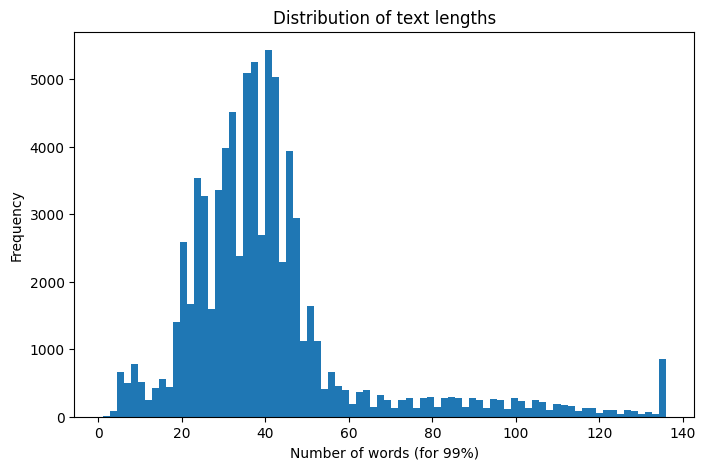

In [351]:
p99 = df["text_len"].quantile(0.99)

plt.figure(figsize=(8,5))
plt.hist(df["text_len"].clip(upper=p99), bins=80)
plt.xlabel("Number of words (for 99%)")
plt.ylabel("Frequency")
plt.title("Distribution of text lengths")
plt.show()

In [352]:
df["source"].value_counts().describe()

count     1359.000000
mean        58.864606
std        624.942213
min          1.000000
25%          1.000000
50%          2.000000
75%          8.000000
max      15850.000000
Name: count, dtype: float64

In [353]:
df["source"].value_counts().head(15)

source
Yahoo            15850
Reuters          11915
BBC               7971
New               6430
Washington        3383
RedNova           2701
Boston            1807
CNN               1802
CNET              1369
Topix.Net         1331
Guardian          1011
Motley             931
Register           834
International      756
Forbes             720
Name: count, dtype: int64

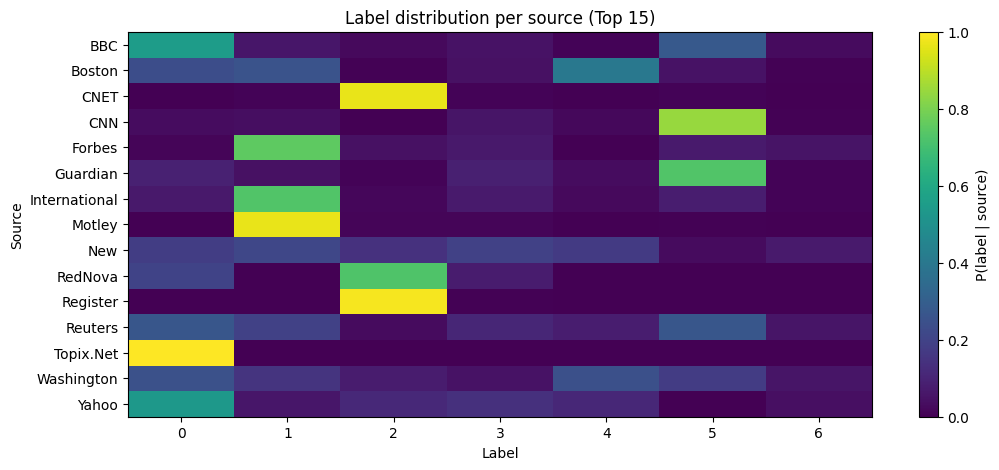

In [9]:
TOP_N = 15

top_sources = df["source"].value_counts().head(TOP_N).index

ct = pd.crosstab(
    df.loc[df["source"].isin(top_sources), "source"],
    df.loc[df["source"].isin(top_sources), "label"],
    normalize="index"
)

plt.figure(figsize=(12,5))
plt.imshow(ct.values, aspect="auto")
plt.colorbar(label="P(label | source)")
plt.xticks(range(ct.shape[1]), ct.columns)
plt.yticks(range(ct.shape[0]), ct.index)
plt.xlabel("Label")
plt.ylabel("Source")
plt.title("Label distribution per source (Top 15)")
plt.show()

In [355]:
def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

source_entropy = (
    pd.crosstab(df["source"], df["label"], normalize="index")
      .apply(entropy, axis=1)
)

source_entropy.describe()

count    1359.000000
mean        0.855459
std         0.860356
min        -0.000000
25%        -0.000000
50%         0.918296
75%         1.551690
max         2.669529
dtype: float64

In [356]:
np.log2(7)

np.float64(2.807354922057604)

An entropy-based analysis showed that the source attribute is highly informative, with an average entropy significantly lower than the random baseline.
This indicates that many publishers are strongly associated with specific categories, making source a valuable complementary feature to textual content.

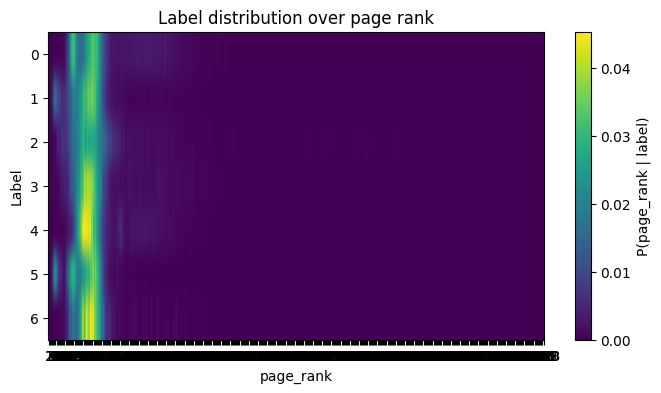

In [16]:
pr_ct = pd.crosstab(df["label"], df["text_len"], normalize="index").sort_index()

plt.figure(figsize=(8,4))
plt.imshow(pr_ct.values, aspect="auto")
plt.colorbar(label="P(page_rank | label)")
plt.xticks(range(pr_ct.shape[1]), pr_ct.columns)
plt.yticks(range(pr_ct.shape[0]), pr_ct.index)
plt.xlabel("page_rank")
plt.ylabel("Label")
plt.title("Label distribution over page rank")
plt.show()

In [358]:
df.loc[df["timestamp"].notna(), "timestamp"].sample(20, random_state=42)

56722    0000-00-00 00:00:00
60844    2006-10-02 23:30:43
74780    0000-00-00 00:00:00
52281    0000-00-00 00:00:00
54595    0000-00-00 00:00:00
8215     2007-02-28 10:21:13
56359    2007-02-17 04:34:44
43072    0000-00-00 00:00:00
66533    2007-02-14 22:03:40
58831    0000-00-00 00:00:00
56721    2007-12-14 02:33:56
833      2007-10-26 21:43:52
51498    2007-08-30 16:14:12
54365    2004-09-30 19:04:36
25540    2007-05-30 00:05:58
36505    2004-10-13 21:27:40
42401    2007-07-09 14:10:57
52590    2007-10-23 21:08:02
38271    0000-00-00 00:00:00
28275    0000-00-00 00:00:00
Name: timestamp, dtype: object

In [359]:
ts = pd.to_datetime(df["timestamp"], errors="coerce")
df.loc[ts.isna(), "timestamp"].sample(20, random_state=42)

3422     0000-00-00 00:00:00
42273    0000-00-00 00:00:00
78709    0000-00-00 00:00:00
49107    0000-00-00 00:00:00
40562    0000-00-00 00:00:00
60517    0000-00-00 00:00:00
19444    0000-00-00 00:00:00
39710    0000-00-00 00:00:00
69933    0000-00-00 00:00:00
42178    0000-00-00 00:00:00
6041     0000-00-00 00:00:00
14155    0000-00-00 00:00:00
6299     0000-00-00 00:00:00
7504     0000-00-00 00:00:00
21538    0000-00-00 00:00:00
33939    0000-00-00 00:00:00
5475     0000-00-00 00:00:00
75983    0000-00-00 00:00:00
68063    0000-00-00 00:00:00
13883    0000-00-00 00:00:00
Name: timestamp, dtype: object

In [360]:
df["timestamp_clean"] = df["timestamp"].replace("0000-00-00 00:00:00", pd.NA)
df["timestamp_dt"] = pd.to_datetime(df["timestamp_clean"], errors="coerce")
df["has_timestamp"] = df["timestamp_dt"].notna().astype(int)
df = df.drop(columns=["timestamp", "timestamp_clean", "timestamp_dt"])
df_eval["timestamp_clean"] = df_eval["timestamp"].replace("0000-00-00 00:00:00", pd.NA)
df_eval["timestamp_dt"] = pd.to_datetime(df_eval["timestamp_clean"], errors="coerce")
df_eval["has_timestamp"] = df_eval["timestamp_dt"].notna().astype(int)
df_eval = df_eval.drop(columns=["timestamp", "timestamp_clean", "timestamp_dt"])

In [361]:
df_eval.shape, df_eval.columns

((20000, 6),
 Index(['Id', 'source', 'page_rank', 'text', 'text_len', 'has_timestamp'], dtype='object'))

In [362]:
df_eval["Id"].isna().sum(), df_eval["Id"].duplicated().sum()

(np.int64(0), np.int64(0))

In [363]:
df_eval.isna().sum()

Id               0
source           0
page_rank        0
text             0
text_len         0
has_timestamp    0
dtype: int64

In [364]:
dev_sources = set(df["source"])
eval_sources = set(df_eval["source"])

len(eval_sources - dev_sources)

116

In [365]:
df_eval["page_rank"].describe()

count    20000.000000
mean         4.891450
std          0.400094
min          2.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: page_rank, dtype: float64

In [366]:
df_eval["has_timestamp"].value_counts(normalize=True)

has_timestamp
1    0.65095
0    0.34905
Name: proportion, dtype: float64

In [367]:
df_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             20000 non-null  int64 
 1   source         20000 non-null  object
 2   page_rank      20000 non-null  int64 
 3   text           20000 non-null  object
 4   text_len       20000 non-null  int64 
 5   has_timestamp  20000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 937.6+ KB


In [416]:
X = df[["text", "source", "page_rank","text_len"]]
y = df["label"]

# -------------------------
# 2) TF-IDF
# -------------------------
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_features=50_000,
    stop_words="english",
    sublinear_tf=True,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

# -------------------------
# 3) Preprocess
# -------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("text", tfidf, "text"),
        ("source", OneHotEncoder(handle_unknown="ignore"), ["source"]),
        ("num", StandardScaler(), ["page_rank","text_len"])
    ]
)


pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", LinearSVC(class_weight="balanced", C=1.0))
    ]
)

# -------------------------
# 5) CV + tuning C in [0.5, 1.0]
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_values = [0.17]

rows = []
for C in C_values:
    pipe.set_params(clf__C=C)  # cambia SOLO C, tutto il resto invariato
    
    scores = cross_val_score(
        pipe,
        X, y,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    
    rows.append({
        "C": C,
        "mean_f1": scores.mean(),
        "std_f1": scores.std(),
        "folds": scores
    })

results = pd.DataFrame(rows).sort_values("mean_f1", ascending=False)
results

,C,mean_f1,std_f1,folds
0,0.17,0.719978,0.001356,"[0.71980699169409, 0.7186757107920047, 0.72009..."
